In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
RANDOM_SEED = 41

In [ ]:
data = load_breast_cancer()
X = data.data[:,:2]
y = data.target
df = pd.DataFrame(data.data[:,:2], columns=data.feature_names[:2])
df['target'] = data.target
df['target'].value_counts()

   mean radius  mean texture  target
0        17.99         10.38       0
1        20.57         17.77       0
2        19.69         21.25       0
3        11.42         20.38       0
4        20.29         14.34       0


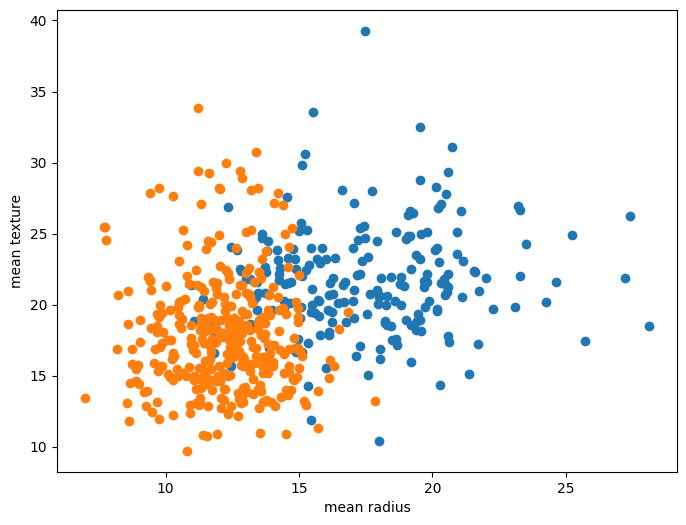

In [3]:
plt.figure(figsize=(8, 6))

for cls, name in enumerate(data.target_names):
    mask = y == cls
    plt.scatter(
        X[mask, 0],
        X[mask, 1],
    )

plt.xlabel(data.feature_names[0])
plt.ylabel(data.feature_names[1])
plt.show()

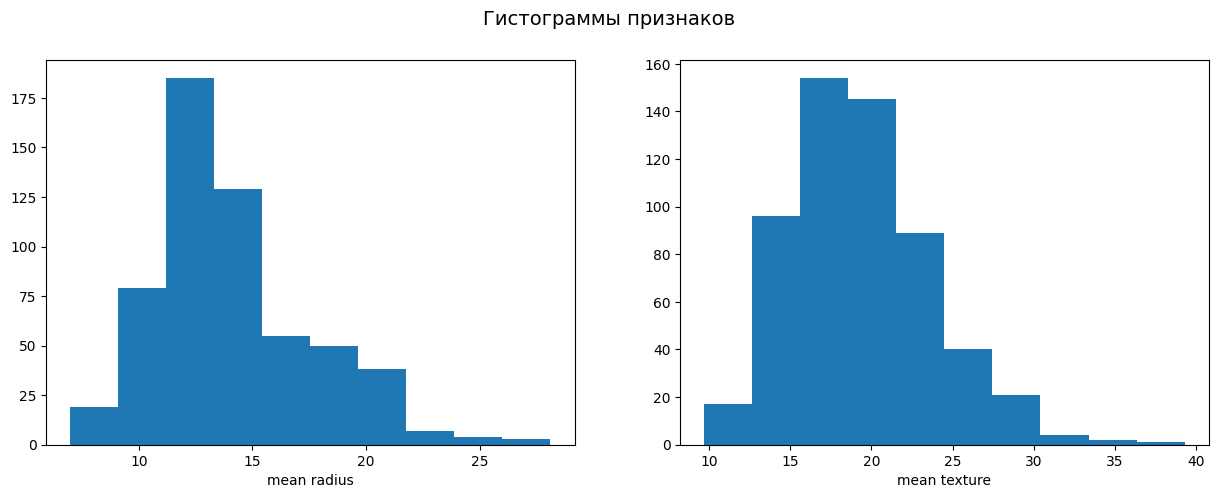

In [4]:
plt.figure(figsize=(15, 5))
for i in range(2):    
    plt.subplot(1, 2, i+1)
    plt.hist(X[:, i])
    plt.xlabel(data.feature_names[i])
plt.suptitle('Гистограммы признаков',fontsize=14)
plt.show()

In [5]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
gaussian_nb = GaussianNB()
gaussian_nb.fit(X, y)
y_pred = gaussian_nb.predict(X)
print(confusion_matrix(y, y_pred))
print('Accuracy= ', accuracy_score(y, y_pred))
print('F1_score= ', f1_score(y, y_pred))

[[164  48]
 [ 17 340]]
Accuracy=  0.8857644991212654
F1_score=  0.912751677852349


In [6]:
X = data.data
y = data.target
X.shape, y.shape
gaussian_nb.fit(X, y)
y_pred = gaussian_nb.predict(X)
print(confusion_matrix(y, y_pred))
print('Accuracy= ', accuracy_score(y, y_pred))
print('F1_score= ', f1_score(y, y_pred))

[[189  23]
 [ 10 347]]
Accuracy=  0.9420035149384886
F1_score=  0.9546079779917469


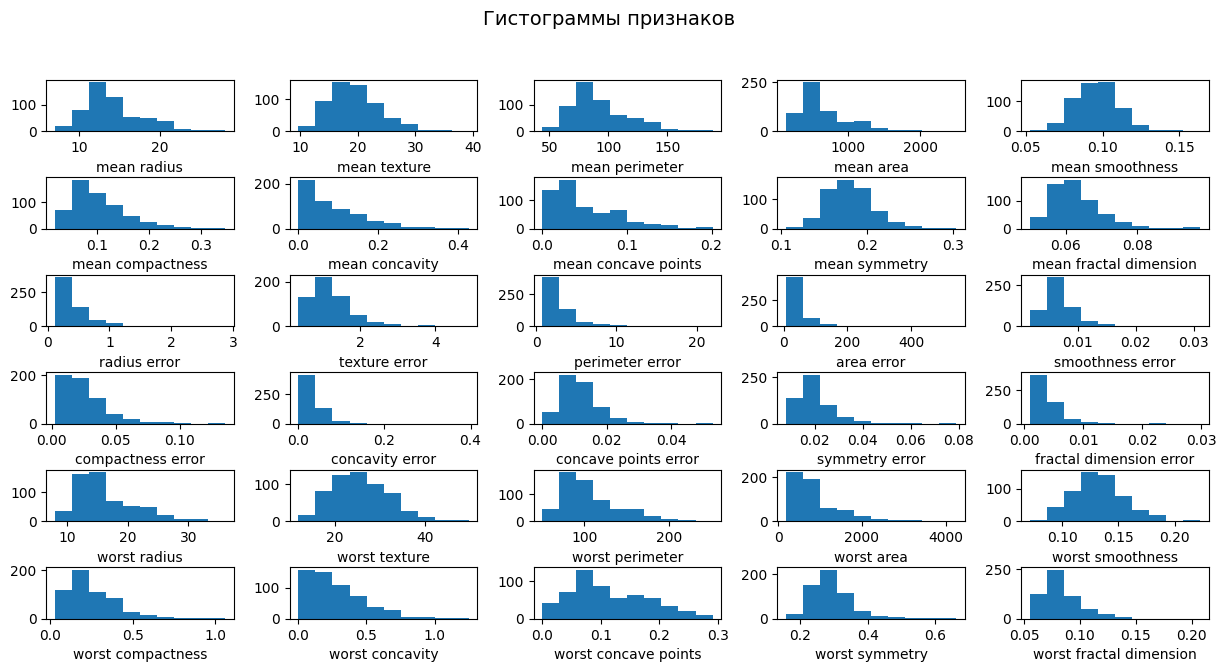

In [7]:
f = plt.figure(figsize=(15, 7))
for i in range(30):
    plt.subplot(6, 5, i+1)
    plt.hist(X[:, i])
    
    plt.xlabel(data.feature_names[i])
f.subplots_adjust(hspace=0.9,wspace=0.3)    
plt.suptitle('Гистограммы признаков',fontsize=14)
plt.show()

In [11]:
data = load_breast_cancer()
X = data.data
y = data.target
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df['target'].value_counts()

todrop = ['mean concavity','radius error', 
              'perimeter error', 'area error', 
              'compactness error', 'concavity error',
              'fractal dimension error', 'worst area', 
              'worst concavity']
for col in todrop:
    df.drop(col, axis=1, inplace=True)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concave points,mean symmetry,mean fractal dimension,texture error,...,symmetry error,worst radius,worst texture,worst perimeter,worst smoothness,worst compactness,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.14710,0.2419,0.07871,0.9053,...,0.03003,25.38,17.33,184.60,0.1622,0.6656,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.07017,0.1812,0.05667,0.7339,...,0.01389,24.99,23.41,158.80,0.1238,0.1866,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.12790,0.2069,0.05999,0.7869,...,0.02250,23.57,25.53,152.50,0.1444,0.4245,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.10520,0.2597,0.09744,1.1560,...,0.05963,14.91,26.50,98.87,0.2098,0.8663,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.10430,0.1809,0.05883,0.7813,...,0.01756,22.54,16.67,152.20,0.1374,0.2050,0.1625,0.2364,0.07678,0


In [12]:
gaussian_nb.fit(X, y)
y_pred = gaussian_nb.predict(X)
print(confusion_matrix(y, y_pred))
print('Accuracy= ', accuracy_score(y, y_pred))
print('F1_score= ', f1_score(y, y_pred))

[[189  23]
 [ 10 347]]
Accuracy=  0.9420035149384886
F1_score=  0.9546079779917469


# task

In [13]:
from sklearn.naive_bayes import (
    MultinomialNB,
    BernoulliNB,
    ComplementNB,
    CategoricalNB,
)
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

bayes_variants = [
    MultinomialNB,
    BernoulliNB,
    ComplementNB,
    CategoricalNB,
]

for cls in bayes_variants:
    print(cls.__name__)
    model = cls()
    model.fit(X, y)
    y_pred = model.predict(X)
    print("confusion matrix:\n", confusion_matrix(y, y_pred))
    print("accuracy =", accuracy_score(y, y_pred))
    print("f1_score =", f1_score(y, y_pred))
    print()

MultinomialNB
confusion matrix:
 [[163  49]
 [ 10 347]]
accuracy = 0.8963093145869947
f1_score = 0.9216467463479415

BernoulliNB
confusion matrix:
 [[  0 212]
 [  0 357]]
accuracy = 0.6274165202108963
f1_score = 0.7710583153347732

ComplementNB
confusion matrix:
 [[163  49]
 [ 11 346]]
accuracy = 0.8945518453427065
f1_score = 0.9202127659574468

CategoricalNB
confusion matrix:
 [[192  20]
 [  3 354]]
accuracy = 0.9595782073813708
f1_score = 0.9685362517099864



In [14]:
titanic_raw = pd.read_csv('data/titanic.csv')
titanic_raw.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,0,22.0,1,0,7.2500,0,0,1
1,2,1,1,1,38.0,1,0,71.2833,1,0,0
2,3,1,3,1,26.0,0,0,7.9250,0,0,1
3,4,1,1,1,35.0,1,0,53.1000,0,0,1
4,5,0,3,0,35.0,0,0,8.0500,0,0,1


In [16]:
X = titanic_raw.drop(['PassengerId', 'Fare'], axis=1)
y = titanic_raw['Survived']

In [17]:
for cls in bayes_variants:
    print(cls.__name__)
    model = cls()
    model.fit(X, y)
    y_pred = model.predict(X)
    print("confusion matrix:\n", confusion_matrix(y, y_pred))
    print("accuracy =", accuracy_score(y, y_pred))
    print("f1_score =", f1_score(y, y_pred))
    print()

MultinomialNB
confusion matrix:
 [[527  22]
 [  0 342]]
accuracy = 0.9753086419753086
f1_score = 0.9688385269121813

BernoulliNB
confusion matrix:
 [[549   0]
 [  0 342]]
accuracy = 1.0
f1_score = 1.0

ComplementNB
confusion matrix:
 [[512  37]
 [  0 342]]
accuracy = 0.9584736251402918
f1_score = 0.9486823855755895

CategoricalNB
confusion matrix:
 [[549   0]
 [  0 342]]
accuracy = 1.0
f1_score = 1.0



In [21]:
kaggle_titanic = pd.read_csv('data/kaggle-titanic.csv')
print(kaggle_titanic.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [ ]:
kaggle = pd.read_csv('data/kaggle-titanic.csv')
kaggle = kaggle.drop(['PassengerId','Name','Ticket','Cabin'], axis=1)
kaggle['Sex'] = kaggle['Sex'].map({'male':0,'female':1})
kaggle['Age'] = kaggle['Age'].fillna(kaggle['Age'].median())
kaggle['Embarked'] = kaggle['Embarked'].fillna(kaggle['Embarked'].mode()[0])

kaggle = pd.get_dummies(kaggle, columns=['Embarked'], drop_first=True)  # one-hot encoding thing

X = kaggle.drop('Survived', axis=1)
y = kaggle['Survived']

model = GaussianNB()
model.fit(X, y)

y_pred = model.predict(X)
print('accuracy =', accuracy_score(y, y_pred))
print('f1_score =', f1_score(y, y_pred))
print('confusion matrix:\n', confusion_matrix(y, y_pred))

accuracy = 0.7901234567901234
f1_score = 0.7229629629629629
confusion matrix:
 [[460  89]
 [ 98 244]]
